In [1]:
import pandas as pd
import numpy as np

# ==========================================
# STEP 1: DATA CLEANING (Linear Interpolation)
# ==========================================
print("--- Step 1: Data Cleaning (with Interpolation) ---")

# 1. Load the dataset
# Load the Excel file
file_path = "/Users/mac/Desktop/econ pdata.xlsx"
df = pd.read_excel(file_path)

# 2. Rename columns for easier access
df = df.rename(columns={
    'Country Name': 'Country',
    'Trade (% of GDP)': 'Trade_Openness',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI_Inflows',
    'GDP per capita (current US$)': 'GDP_per_capita',
    'Inflation, consumer prices (annual %)': 'Inflation',
    'Individuals using the Internet (% of population)': 'Internet_Penetration',
    'DSTRI (Index: 1 = maximum restriction)': 'DSTRI'
})

# 3. Convert columns to numeric
# The 'errors="coerce"' argument turns non-numeric text (like "..") into NaN (Not a Number)
cols_to_clean = ['Trade_Openness', 'Internet_Penetration', 'FDI_Inflows', 
                 'GDP_per_capita', 'Inflation', 'DSTRI']

for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Sort Data
# Essential for interpolation: Data must be ordered by Country and Year
df = df.sort_values(by=['Country', 'Year'])

# 5. Apply Linear Interpolation
# We group by 'Country' so we don't interpolate between different countries.
print(f"Missing values before interpolation:\n{df.isnull().sum()}")

# Apply interpolation to the specific numeric columns
# limit_direction='both' allows filling leading/trailing gaps if reasonable, 
# but standard linear usually fills gaps inside the series.
df[cols_to_clean] = df.groupby('Country')[cols_to_clean].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# 6. Drop remaining NaNs
# Interpolation might fail if a country has NO data for a variable, 
# or sometimes at the very edges if limit_direction isn't sufficient.
df_clean = df.dropna()

print(f"\nMissing values after interpolation and final drop:\n{df_clean.isnull().sum()}")
print(f"\nOriginal shape: {df.shape}")
print(f"Final Cleaned shape: {df_clean.shape}")

# 7. Save to CSV for the next analysis step
df_clean.to_csv('cleaned_econ_data_interpolated.csv', index=False)
print("Cleaned data saved to 'cleaned_econ_data_interpolated.csv'")

--- Step 1: Data Cleaning (with Interpolation) ---
Missing values before interpolation:
Country                  0
Year                     0
Trade_Openness           1
FDI_Inflows              0
GDP_per_capita           0
Inflation                0
Internet_Penetration    12
DSTRI                    0
dtype: int64

Missing values after interpolation and final drop:
Country                 0
Year                    0
Trade_Openness          0
FDI_Inflows             0
GDP_per_capita          0
Inflation               0
Internet_Penetration    0
DSTRI                   0
dtype: int64

Original shape: (150, 8)
Final Cleaned shape: (150, 8)
Cleaned data saved to 'cleaned_econ_data_interpolated.csv'


--- Step 2: Descriptive Analysis ---
Data loaded successfully.

Summary Statistics:
              Year  Trade_Openness  FDI_Inflows  GDP_per_capita   Inflation  \
count   150.000000      150.000000   150.000000      150.000000  150.000000   
mean   2019.500000       67.246173     2.620274    39422.890029    4.629968   
std       2.881904       48.366179     7.871729    26233.933002    8.856192   
min    2015.000000       23.079778   -28.307232     1583.998159   -0.330960   
25%    2017.000000       39.088400     0.938056    10351.573034    1.240584   
50%    2019.500000       59.269645     1.688494    43138.261570    2.508037   
75%    2022.000000       72.791092     3.063480    54800.180743    5.086814   
max    2024.000000      252.962925    74.745165   107316.337307   72.308836   

       Internet_Penetration       DSTRI  
count            150.000000  150.000000  
mean              81.887395    0.130400  
std               17.414053    0.108849  
min               14.900000    0.000

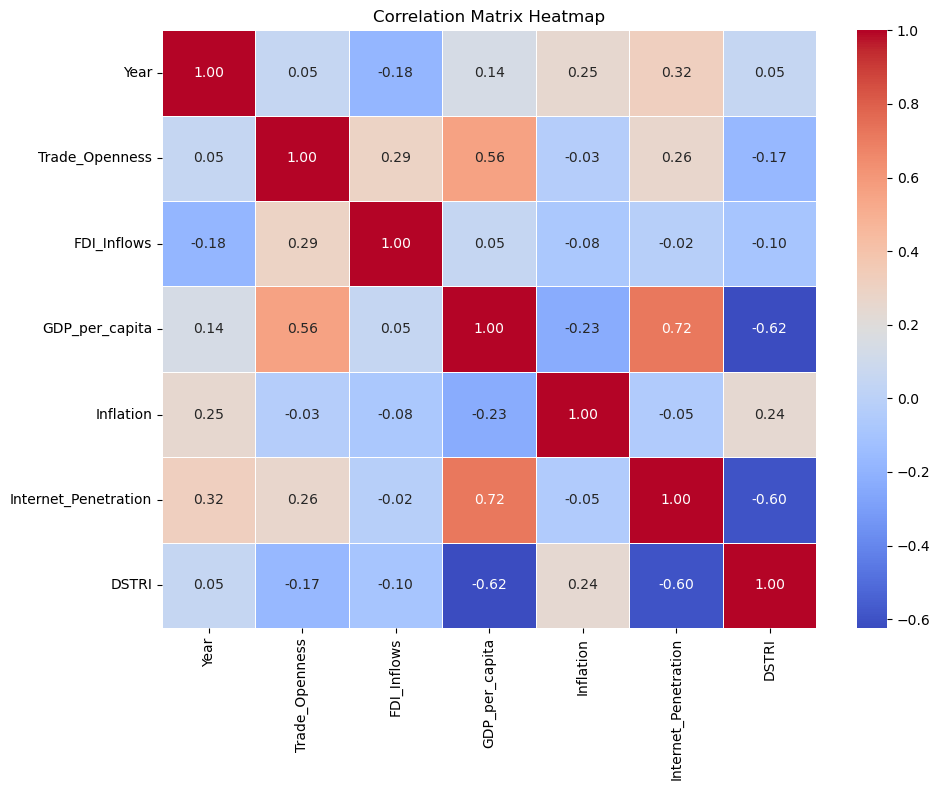

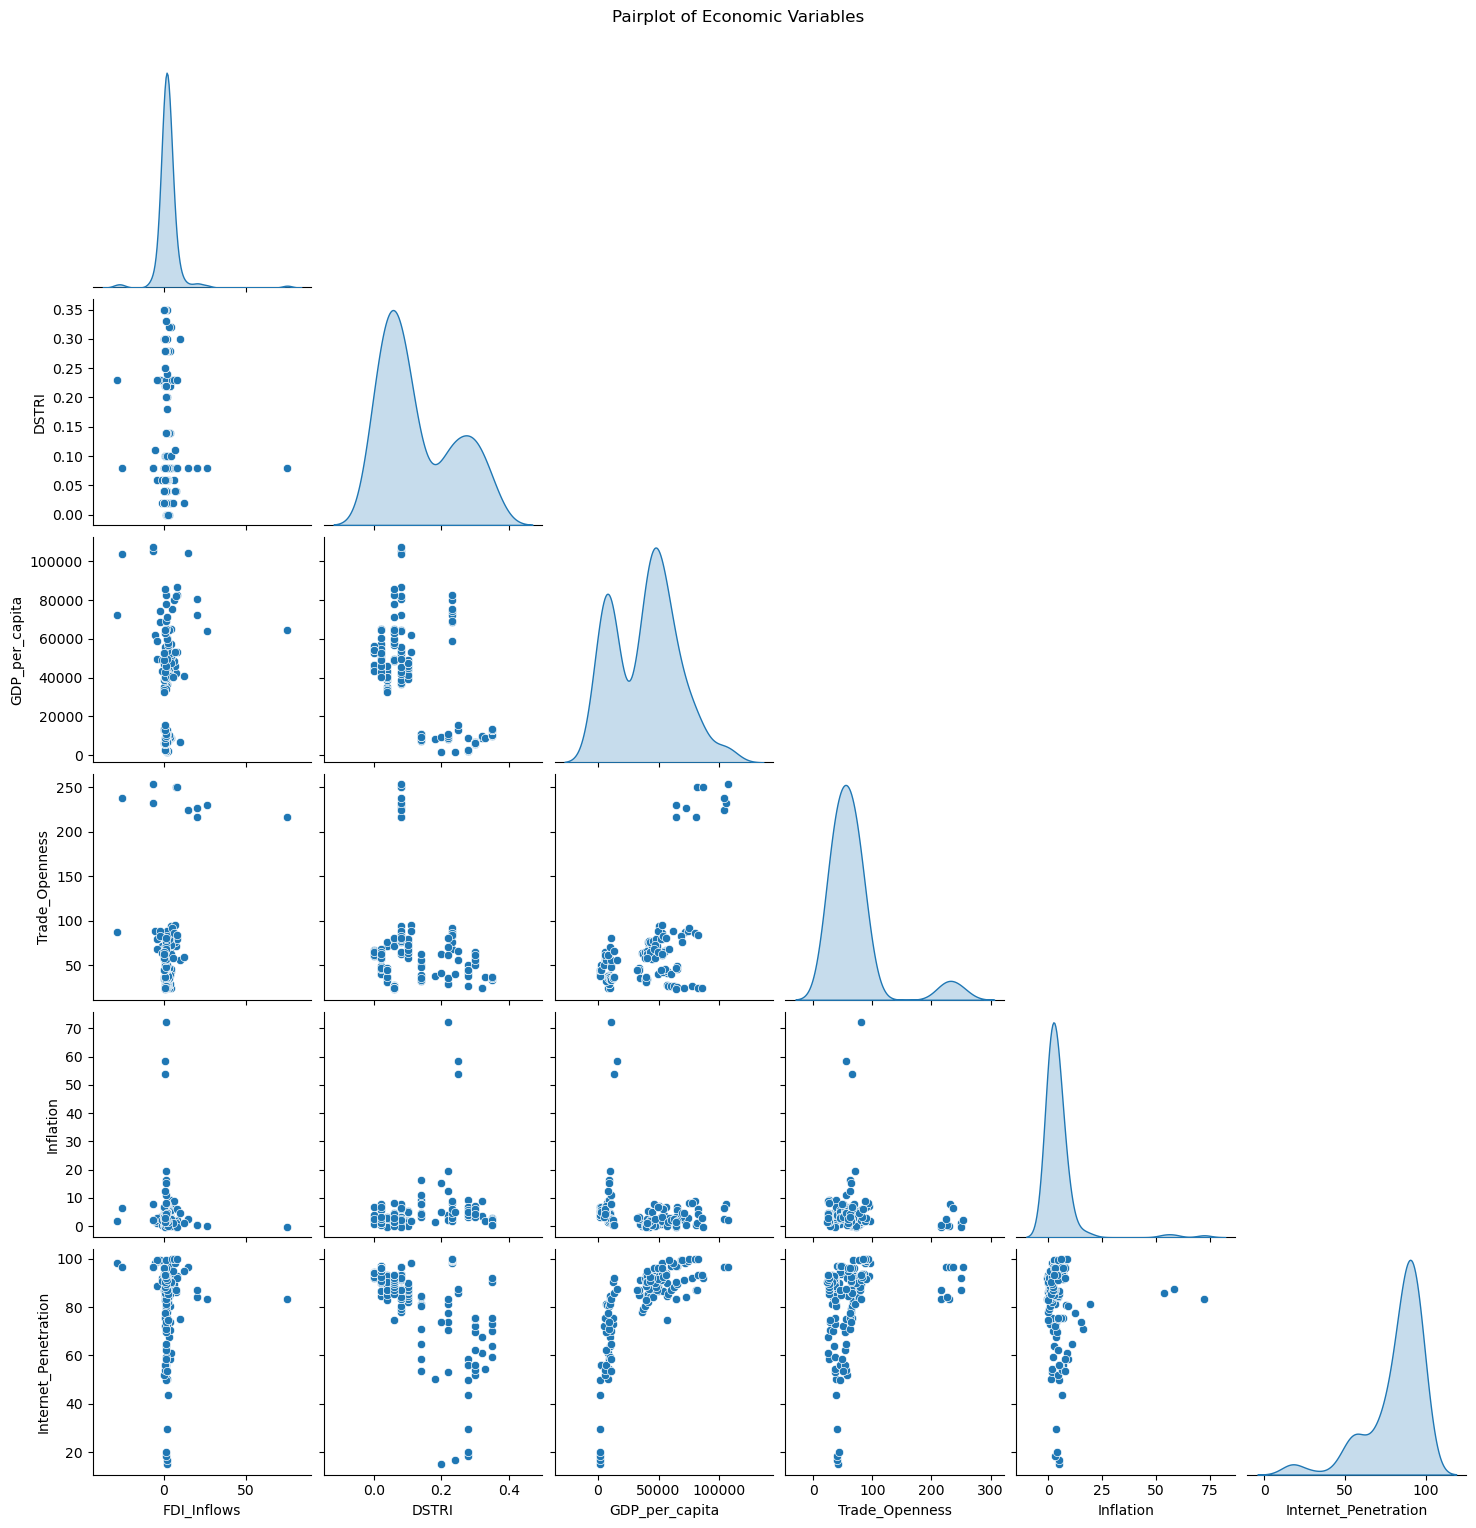

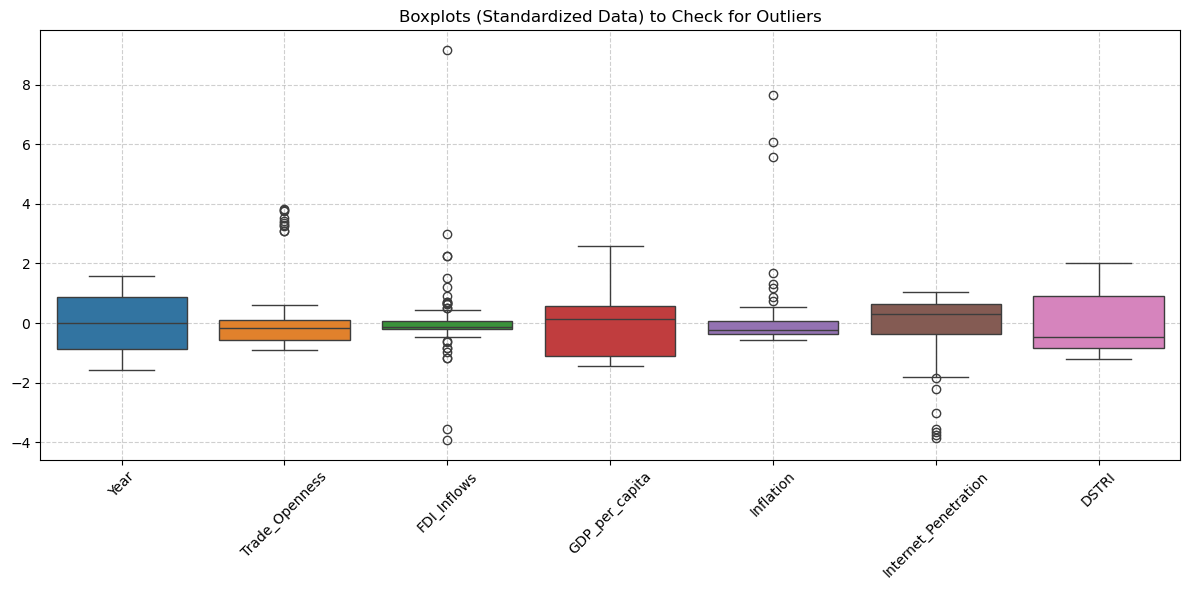


Descriptive analysis complete. Check the plots for visual insights.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# STEP 2: DESCRIPTIVE ANALYSIS
# ==========================================
print("--- Step 2: Descriptive Analysis ---")

# 1. Load the cleaned data from the previous step
try:
    df = pd.read_csv('cleaned_econ_data_interpolated.csv')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'cleaned_econ_data_interpolated.csv' not found. Please run the data cleaning script first.")
    exit()

# 2. Summary Statistics
# This gives you Mean, Standard Deviation, Min, Max, and Quartiles
desc_stats = df.describe()
print("\nSummary Statistics:")
print(desc_stats)

# Save summary stats to CSV for your report
desc_stats.to_csv('descriptive_statistics.csv')

# 3. Correlation Matrix
# We only select numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# 4. Visualizations

# A. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# B. Pairplot (Scatter plots for all variable pairs)
# This helps visualize linear relationships and potential outliers
# We exclude 'Year' to focus on economic variables
vars_to_plot = ['FDI_Inflows', 'DSTRI', 'GDP_per_capita', 'Trade_Openness', 'Inflation', 'Internet_Penetration']
sns.pairplot(df[vars_to_plot], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Economic Variables', y=1.02)
plt.show()

# C. Boxplots (To check for Outliers)
plt.figure(figsize=(12, 6))
# We standardize data temporarily just for the boxplot so variables with huge numbers (like GDP) 
# don't hide the variation in small numbers (like DSTRI)
df_normalized = (numeric_df - numeric_df.mean()) / numeric_df.std()
sns.boxplot(data=df_normalized)
plt.xticks(rotation=45)
plt.title('Boxplots (Standardized Data) to Check for Outliers')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nDescriptive analysis complete. Check the plots for visual insights.")

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# ==========================================
# DIAGNOSTIC TESTS (Steps 3, 4, & 5)
# ==========================================
print("--- Diagnostic Tests ---")

# 1. Load the cleaned data
try:
    df = pd.read_csv('cleaned_econ_data_interpolated.csv')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'cleaned_econ_data_interpolated.csv' not found. Please run the data cleaning script first.")
    exit()

--- Diagnostic Tests ---
Data loaded successfully.


In [11]:
# ---------------------------------------------------------
# PRELIMINARY: Fit a Basic OLS Model
# ---------------------------------------------------------
# We need to fit a model first because Heteroskedasticity and 
# Autocorrelation tests are performed on the model's residuals (errors).
# Formula: FDI ~ DSTRI + Controls
model = ols('FDI_Inflows ~ DSTRI + GDP_per_capita + Trade_Openness + Inflation + Internet_Penetration', 
            data=df).fit()
# PRINT THE OLS SUMMARY
print("\n[OLS Regression Results]")
print(model.summary())


[OLS Regression Results]
                            OLS Regression Results                            
Dep. Variable:            FDI_Inflows   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     4.843
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           0.000400
Time:                        00:25:06   Log-Likelihood:                -510.17
No. Observations:                 150   AIC:                             1032.
Df Residuals:                     144   BIC:                             1050.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Interc

In [13]:
# STEP 3: MULTICOLLINEARITY TEST (VIF)
# ---------------------------------------------------------
print("\n--- Step 3: Multicollinearity Test (VIF) ---")

# VIF requires a dataframe of just the independent variables (including a constant/intercept)
X_vars = df[['DSTRI', 'GDP_per_capita', 'Trade_Openness', 'Inflation', 'Internet_Penetration']]
# Add a constant column (intercept) for the calculation
X_with_const = sm.add_constant(X_vars)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data)
print("\nInterpretation Rule: VIF > 5 or 10 indicates problematic multicollinearity.")


--- Step 3: Multicollinearity Test (VIF) ---
               Variable        VIF
0                 const  51.644711
1                 DSTRI   1.902488
2        GDP_per_capita   3.808105
3        Trade_Openness   1.652963
4             Inflation   1.149294
5  Internet_Penetration   2.464769

Interpretation Rule: VIF > 5 or 10 indicates problematic multicollinearity.


In [15]:
# STEP 4: HETEROSKEDASTICITY TEST (Breusch-Pagan)
# ---------------------------------------------------------
print("\n--- Step 4: Heteroskedasticity Test (Breusch-Pagan) ---")

# Perform test on the model residuals
bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
# Zip creates a dictionary matching labels to the test results
bp_results = dict(zip(labels, bp_test))

print("Breusch-Pagan Test Results:")
for key, value in bp_results.items():
    print(f"{key}: {value:.5f}")

print("\nInterpretation Rule: If p-value < 0.05, Heteroskedasticity is PRESENT (Bad).")


--- Step 4: Heteroskedasticity Test (Breusch-Pagan) ---
Breusch-Pagan Test Results:
LM Statistic: 23.13566
LM-Test p-value: 0.00032
F-Statistic: 5.25212
F-Test p-value: 0.00018

Interpretation Rule: If p-value < 0.05, Heteroskedasticity is PRESENT (Bad).


In [17]:
# STEP 5: AUTOCORRELATION TEST (Durbin-Watson)
# ---------------------------------------------------------
print("\n--- Step 5: Autocorrelation Test (Durbin-Watson) ---")

dw_stat = durbin_watson(model.resid)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

print("\nInterpretation Rule:")
print("  ~ 2.0 : No Autocorrelation (Ideal)")
print("  < 1.5 : Positive Autocorrelation (Common in time series)")
print("  > 2.5 : Negative Autocorrelation")


--- Step 5: Autocorrelation Test (Durbin-Watson) ---
Durbin-Watson Statistic: 1.3598

Interpretation Rule:
  ~ 2.0 : No Autocorrelation (Ideal)
  < 1.5 : Positive Autocorrelation (Common in time series)
  > 2.5 : Negative Autocorrelation


In [23]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.1 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 25.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.0/425.0 kB 17.0 kB/s eta 0:00:0000:0100:02


In [25]:
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare

# 2. Set Panel Index (Entity, Time)
# This is crucial for Panel Data models
df = df.set_index(['Country', 'Year'])

# 3. Define Formula
# FDI is Dependent; DSTRI + Controls are Independent
formula = 'FDI_Inflows ~ 1 + DSTRI + GDP_per_capita + Trade_Openness + Inflation + Internet_Penetration'

# ==========================================
# PART 1: ESTIMATE FE & RE MODELS
# ==========================================
print("\n[1] Running Fixed Effects (FE) Model...")
# EntityEffects=True captures the "Country-Specific" factors
model_fe = PanelOLS.from_formula(formula + ' + EntityEffects', data=df)
results_fe = model_fe.fit()
print(results_fe.summary)

print("\n[2] Running Random Effects (RE) Model...")
model_re = RandomEffects.from_formula(formula, data=df)
results_re = model_re.fit()
print(results_re.summary)


[1] Running Fixed Effects (FE) Model...
                          PanelOLS Estimation Summary                           
Dep. Variable:            FDI_Inflows   R-squared:                        0.3057
Estimator:                   PanelOLS   R-squared (Between):             -86.318
No. Observations:                 150   R-squared (Within):               0.3057
Date:                Mon, Dec 01 2025   R-squared (Overall):             -13.136
Time:                        01:00:05   Log-likelihood                   -481.82
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      11.448
Entities:                          15   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(5,130)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):       

In [27]:
# PART 2: HAUSMAN TEST
# ==========================================
print("\n[3] Performing Hausman Test...")

# Calculate the Hausman Test Statistic manually (Standard Method)
# Formula: (b_fe - b_re)' * [V_fe - V_re]^-1 * (b_fe - b_re)
b_fe = results_fe.params
b_re = results_re.params
v_fe = results_fe.cov
v_re = results_re.cov

# We focus on the common coefficients (excluding the intercept/constant often dropped in FE)
common_coefs = list(set(b_fe.index) & set(b_re.index))
# Remove 'Intercept' if present in comparison, as FE absorbs it into effects
if 'Intercept' in common_coefs: 
    common_coefs.remove('Intercept')
if 'const' in common_coefs:
    common_coefs.remove('const')

b_fe_res = b_fe[common_coefs]
b_re_res = b_re[common_coefs]
v_fe_res = v_fe.loc[common_coefs, common_coefs]
v_re_res = v_re.loc[common_coefs, common_coefs]

# Calculate differences
diff = b_fe_res - b_re_res
diff_cov = v_fe_res - v_re_res

# Calculate Chi-Square Statistic
try:
    hausman_stat = diff.dot(np.linalg.inv(diff_cov)).dot(diff)
    df_hausman = len(diff)
    p_value = 1 - stats.chi2.cdf(hausman_stat, df_hausman)
except np.linalg.LinAlgError:
    print("Warning: Matrix singularity in Hausman test. Results may be unstable.")
    hausman_stat = 0
    p_value = 1.0

print(f"Hausman Test Statistic: {hausman_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print(">> Conclusion: REJECT Null Hypothesis.")
    print(">> Result: FIXED EFFECTS model is appropriate.")
    chosen_model = "FE"
else:
    print(">> Conclusion: FAIL TO REJECT Null Hypothesis.")
    print(">> Result: RANDOM EFFECTS model is appropriate.")
    chosen_model = "RE"


[3] Performing Hausman Test...
Hausman Test Statistic: 54.1435
P-Value: 0.0000
>> Conclusion: REJECT Null Hypothesis.
>> Result: FIXED EFFECTS model is appropriate.


In [29]:
# PART 3: FINAL ROBUST MODEL
# ==========================================
print(f"\n[4] Estimating Final {chosen_model} Model with Clustered Standard Errors...")

if chosen_model == "FE":
    # Re-run PanelOLS (Fixed Effects)
    final_mod = PanelOLS.from_formula(formula + ' + EntityEffects', data=df)
    # cov_type='clustered' fixes Heteroskedasticity AND Autocorrelation
    # cluster_entity=True clusters errors by Country
    final_res = final_mod.fit(cov_type='clustered', cluster_entity=True)
else:
    # Re-run RandomEffects
    # Note: RE with clustered errors is less common in this specific library syntax,
    # but we will apply robust covariances if selected.
    final_mod = RandomEffects.from_formula(formula, data=df)
    final_res = final_mod.fit(cov_type='robust')

print("\n" + "="*50)
print("FINAL ROBUST REGRESSION RESULTS (Use this for report)")
print("="*50)
print(final_res)
print("="*50)


[4] Estimating Final FE Model with Clustered Standard Errors...

FINAL ROBUST REGRESSION RESULTS (Use this for report)
                          PanelOLS Estimation Summary                           
Dep. Variable:            FDI_Inflows   R-squared:                        0.3057
Estimator:                   PanelOLS   R-squared (Between):             -86.318
No. Observations:                 150   R-squared (Within):               0.3057
Date:                Mon, Dec 01 2025   R-squared (Overall):             -13.136
Time:                        01:03:13   Log-likelihood                   -481.82
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.448
Entities:                          15   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(5,130)
Min Obs:                      10.0000                                 